## 2.3 Gradient Based Methods

* There are many methods/algorithms that can be used to find the minimum of a function.  
* In this notebook we will be looking at the details of gradient based techniques.  
* These techniques require information about the value of the function and its gradient.  i.e. in order to find the location of the minimum of a function $f(x)$, we will need to be able to calculate $df/dx$ and $d^2f/dx^2$.
* For this notebook, we will look at methods needing only information about the value of the function $f(x)$ and its gradient $df/dx$. Methods requiring $d^2f/dx^2$ will be covered in the next notebook.

---

Load the libraries needed for this notebook 

In [9]:
using CairoMakie

Define a struct to store data during iterations

In [10]:
struct Point1D
    x::Float64 #guess locations of the minimum
    fvalue::Float64 # value of the function at the guess locations
end

---

# **Example 2.3.1**
We start this notebook by applying gradient descent to find the minimum of the function $f(x)=x^2-2x+0.6$.  As usual, you should always plot the function to see how it looks like.  

<u>Exercise Ex01:</u>  Prove to yourself that this function has a local minimum at $x=1$.

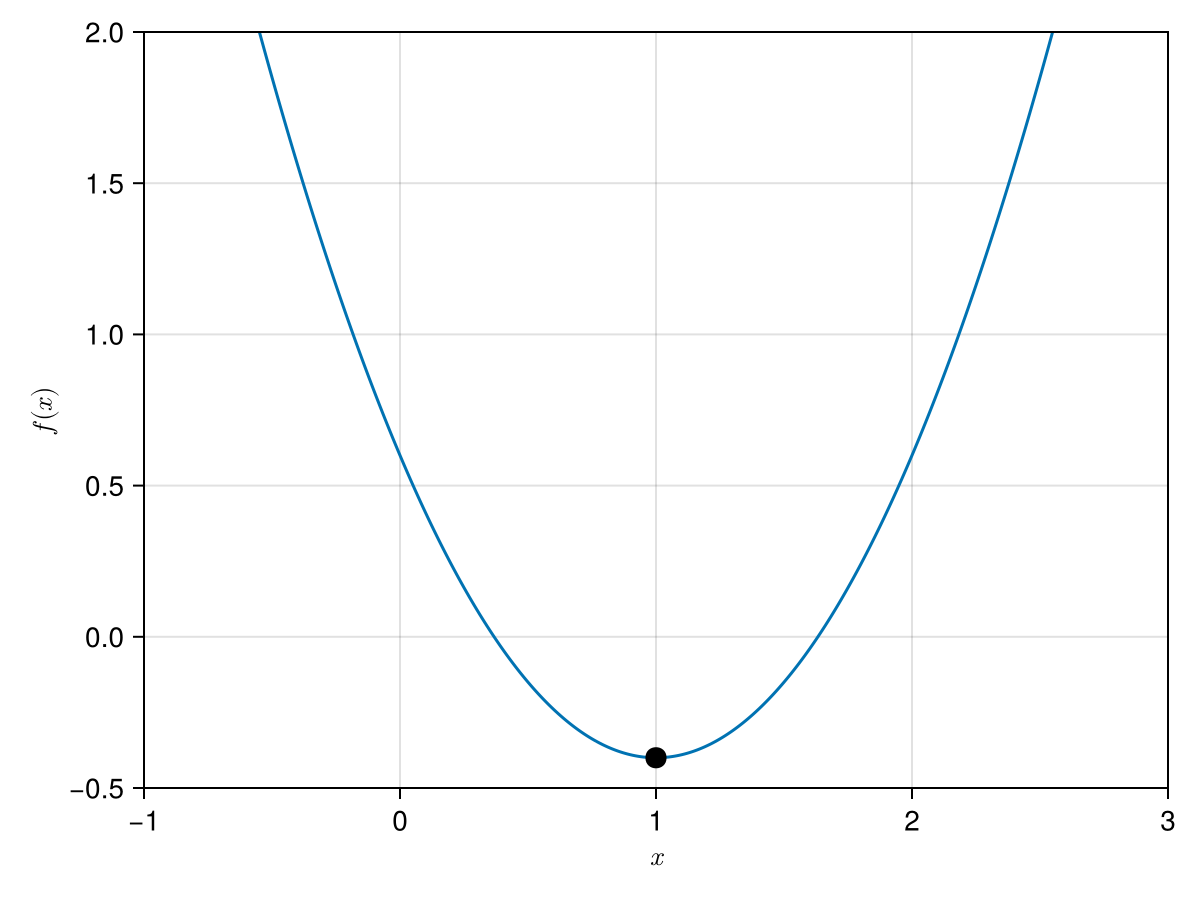

CairoMakie.Screen{IMAGE}


In [11]:
f(x)=x^2-2x+0.6 #Define the function
∇f(x)=2x-2 #Define the gradient of the function


xrange=-1:0.01:3
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)",limits=(-1,3,-0.5,2.0))
lines!(ax,xrange,f.(xrange))
scatter!(ax,1.0,f.(1.0);color=:black,markersize=15)
display(fig)

## Standard Gradient Descent method

* The standard gradient descent method uses the gradient of the function to obtain a better guess for the location of the local minimum of the function.  
* The idea is that if you move in the opposite (-ve) direction of the gradient, the value of the function will always decrease.
* If you repeat this many times, you will eventually reach the location of the local minimum of the function.
* In practice, you will want to move a fraction $\alpha$ of the gradient.  $\alpha$ is called the learning rate.

* The update of equation for the standard gradient descent is given by

    $x^{(k+1)}=x^{(k)}-\alpha g^{(k)}$

    where 
    $g^{(k)}=\frac{df}{dx}(x^{(k)})$ is the gradient of the function $f(x)$ evaluated at the previous guess $x^{(k)}$.  $\alpha$ is the learning rate and is usually given a small value (e.g. $0.1, 0.001$).  The superscript $(k)$ indicates the $k$'th interation.

The code below implements the Gradient Descent method to find the minimum of the $f(x)$

In [12]:
x0=2.5 #initial guess of x0
alpha=0.1 #learning rate
data=[Point1D(x0,f(x0))] #Store the initial value of the guess and the function value into a struct called data
x=x0
for i in 1 : 20
    x-=alpha*∇f(x) #standard gradient descent update equation
    push!(data,Point1D(x,f(x))) #store x and f(x) into data
end

Plot the convergene of $x^{(k)}$

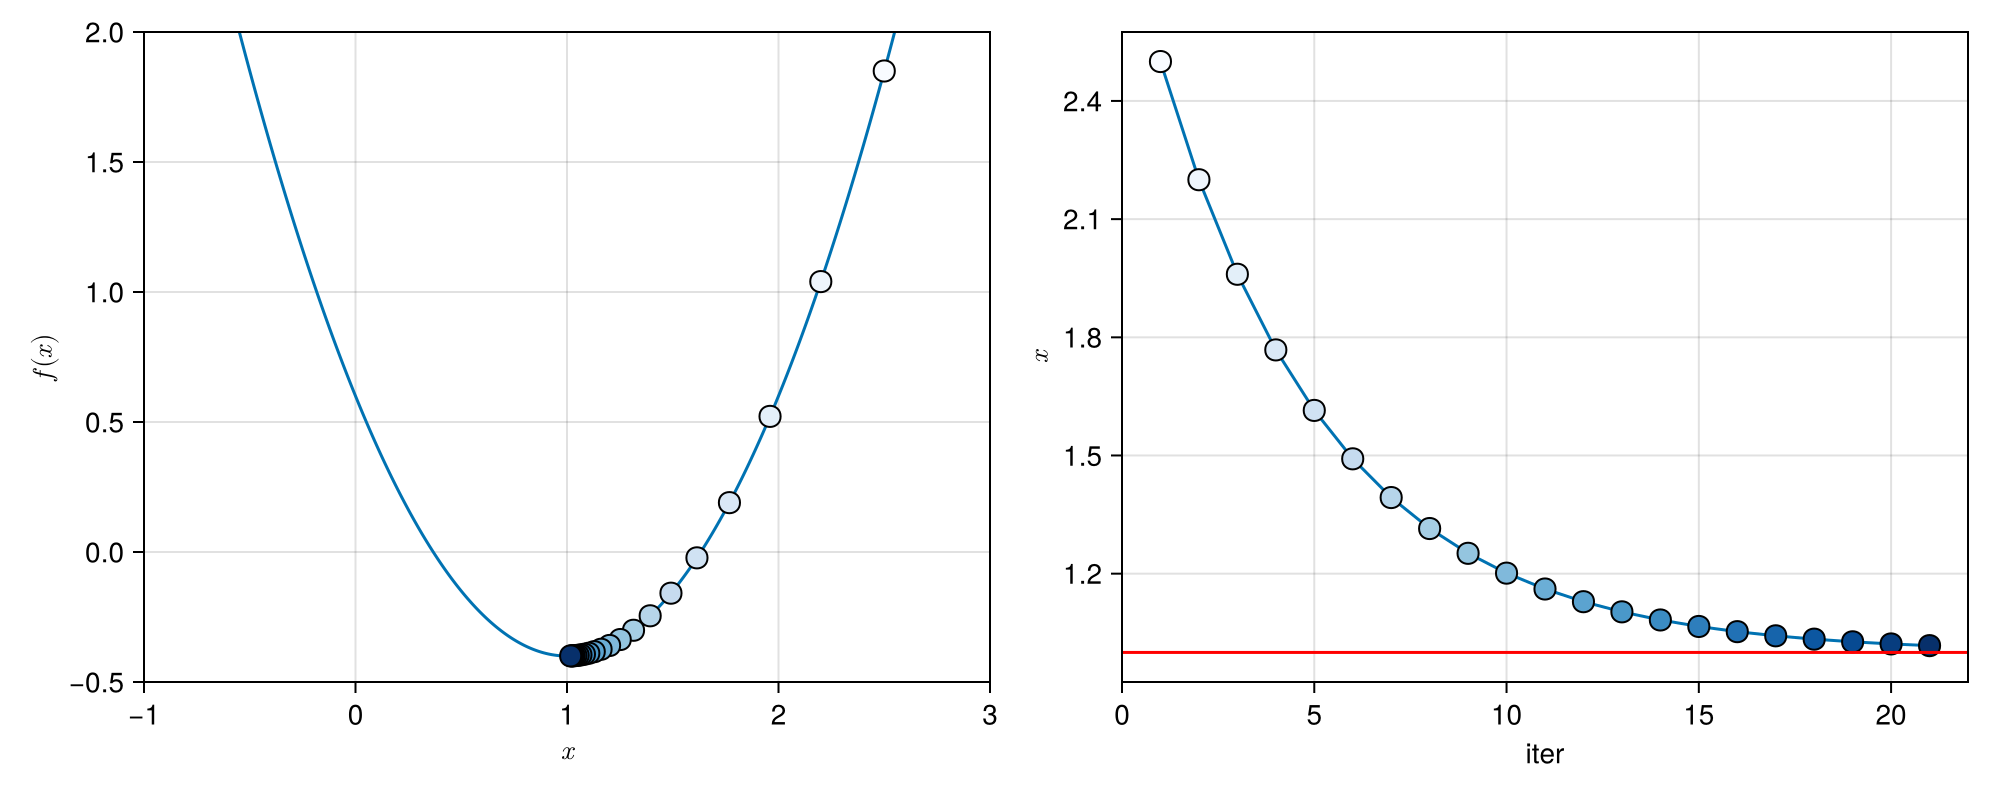

CairoMakie.Screen{IMAGE}


In [13]:
fig_conv = Figure(size=(1000, 400))

ax_conv1 = Axis(fig_conv[1, 1], xlabel = L"x", ylabel = L"f(x)",limits=(-1,3,-0.5,2.0))
lines!(ax_conv1,xrange,f.(xrange))
scatter!(ax_conv1,getproperty.(data,:x),getproperty.(data,:fvalue);
    color=1:length(data),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Blues,
    markersize=15)


ax_conv2 = Axis(fig_conv[1, 2], xlabel = "iter", ylabel = L"x")
lines!(ax_conv2,getproperty.(data, :x),label="Gradient Descent")
scatter!(ax_conv2,getproperty.(data,:x);
    color=1:length(data),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Blues,
    markersize=15)
hlines!(ax_conv2,1.0;color=:red)
save("../figures/02p03GradientBasedMethods01.svg",fig_conv)
display(fig_conv)


* The left figure shows that the solution keeps going towards the minimum of $f(x)$.  

* The location of the minimum is shown in the right figure and shows that it converges to $x=1$ (the red horizontal line).

* You can see from the above that the gradient descent method converges to the minimimum $x_{min}=1.0$.  
* Note that as we get closer and closer to the minimum, the difference between the $x$'s gets smaller and smaller.  This is because as we approach the minimum, the gradient of $f(x)$ gets smaller and smaller and eventually approaches zero.  

* If you look at the update formula for standard gradient descent method, you should be able to see that


    $x^{(k+1)} \approx x^{(k)}$

    providing that $g^{(k)}$ is small.


<u>Exercise Ex02:</u>  Run the code above again with $\alpha=0.01, 0.5$ and 0.8. Comment on the convergece of the solution for small and large values of $\alpha$.

## Example 2.3.1 with Momentum method


* One of the main problems with the standard gradient descent method is that it slows down quite a bit when we approach the minimum of the function
* This is usually not a problem for simple problem but for more complex problems involving lots of variables, we might have to wait ages before we obtain a good solution.
*  The momentum method speeds up convergence, especially closer to the location of the minimum.  

* The update equations for the momentum method is
    $\begin{align}
    v^{(k+1)}&=\beta v^{(k)}-\alpha g^{(k)} \\
    x^{(k+1)}&=x^{(k)}+v^{(k+1)}
    \end{align}$

    where 
$g^{(k)} = \nabla f(x^{(k)})$, $\alpha$ is the learning rate and $\beta$ is the momentum decay.  The variable $v$ can be thought of as the velocity. $v^{(0)}$ is usually set to be zero. 

* It is insightful to write down the first few iterations of the momentum update equations
$\begin{align}
v^{(1)}&=-\alpha g^{(0)}\\
x^{(1)}&=x^{(0)}+v^{(1)}\end{align}$

$\begin{align}
v^{(2)}&=\beta v^{(1)} -\alpha g^{(1)} = -\beta  \alpha g^{(0)} -\alpha g^{(1)}\\
x^{(2)}&=x^{(1)}+v^{(2)}=x^{(1)}-\beta  \alpha g^{(0)} -\alpha g^{(1)}\end{align}$

$\begin{align}
v^{(3)}&=\beta v^{(2)} -\alpha g^{(2)} = -\beta^2  \alpha g^{(0)} -\beta \alpha g^{(1)}-\alpha g^{(2)}\\
x^{(3)}&=x^{(2)}+v^{(3)}=x^{(2)}-\beta^2  \alpha g^{(0)} -\beta \alpha g^{(1)}-\alpha g^{(2)}\end{align}$


* It is clear from the equations above that the momentum method remembers the past gradients.  The higher the value of $\beta$, the more information it retains from the previous gradients. 
* Note that if you set $\beta=0$, you will get back the equations for the standard gradient descent method.  
* The standard gradient descent only uses information about the local gradient.  It "forgets" all the previous gradients.  The momentum method retains information about all previous gradients.

In [14]:
x0=2.5 #initial guess of x0
alpha=0.1 #learning rate
beta=0.6 #momentum
v=0.0 # setting the initial velocity to be zero.  
x=x0
data_m=[Point1D(x0,f(x0))]
for i in 1 : 20
    v=beta*v-alpha*∇f(x) #update equation for the momentum method. 
    x+=v #update equation for the momentum method. 
    push!(data_m,Point1D(x,f(x)))
end

## Example 2.3.1 with Nesterov Momentum method

* Often, the momentum method overshoots the minimum point.  This can be somehow circumvented by the Nesterov Momentum method. 

*  The Nesterov momentum method evaluates the gradient at the future projected location (rather than the current location).  

* The update equations for the Nesterov momentum equations is

    $\begin{align}
    v^{(k+1)}&=\beta v^{(k)}-\alpha g^{(k)} \\
    x^{(k+1)}&=x^{(k)}+v^{(k+1)}
    \end{align}$

    where 
    $g^{(k)} = \nabla f(x^{(k)}+\beta v^{(k)})$.

* The only different between the momentum Nesterov momentum update equations is that the gradient is now evaluated at  $x^{(k)}+\beta v^{(k)}$ (for Nesterov Momentum) instead of $x^{(k)}$ (Momentum).

In [15]:
x0=2.5 #initial guess of xm
alpha=0.1 #learning rate
beta=0.6
v=0.0
x=x0
data_nm=[Point1D(x0,f(x0))]
for i in 1 : 20
    v =beta*v-alpha*∇f(x+beta*v) #update equations for the Nesterov Momentum 
    x+=v #update equations for the Nesterov Momentum 
    push!(data_nm,Point1D(x,f(x)))
end

Now we plot the convence to analyse the properties of the different methods. 

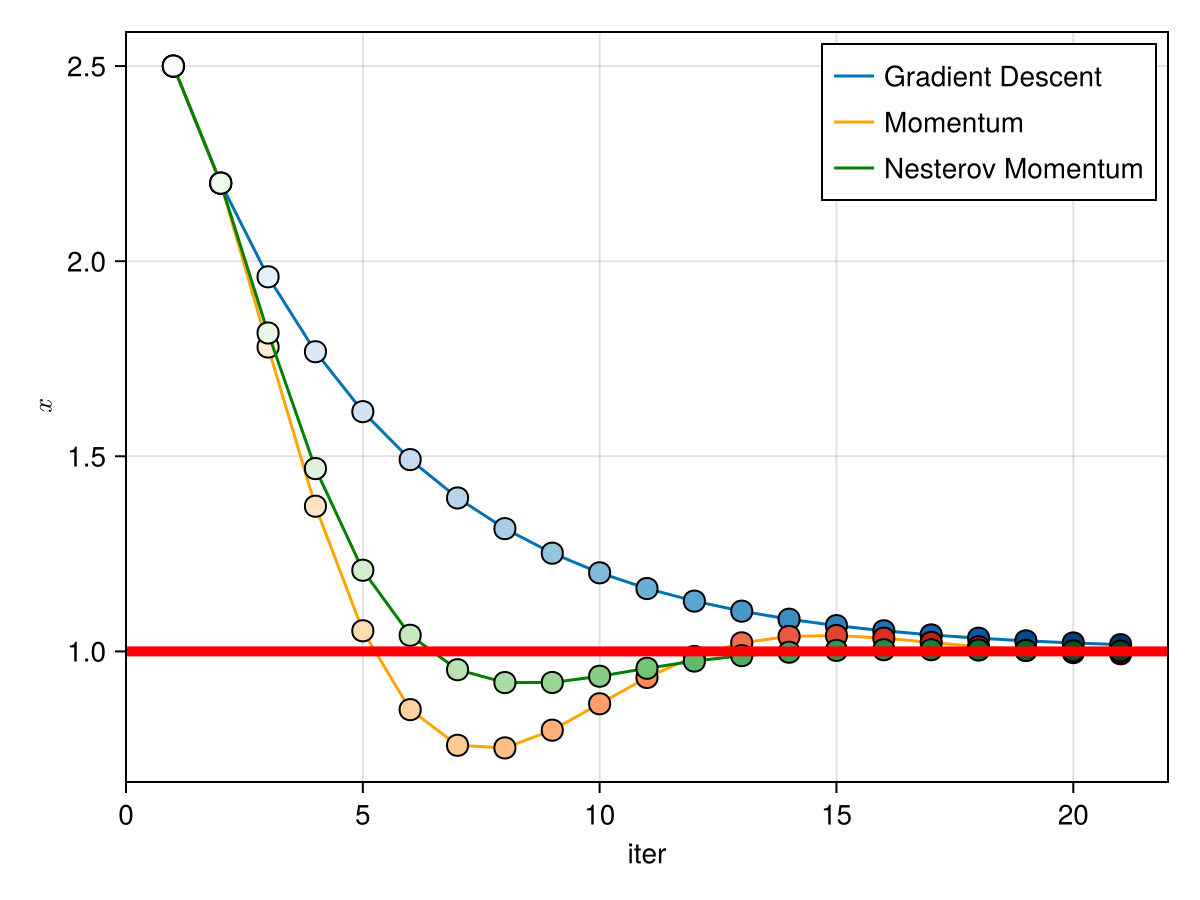

CairoMakie.Screen{IMAGE}


In [17]:
fig_conv = Figure()
ax_conv = Axis(fig_conv[1, 1], xlabel = "iter", ylabel = L"x")

lines!(ax_conv,getproperty.(data, :x),label="Gradient Descent")
scatter!(ax_conv,getproperty.(data,:x);
    color=1:length(data),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Blues,
    markersize=15)

lines!(ax_conv,getproperty.(data_m, :x),label="Momentum",color=:orange)
scatter!(ax_conv,getproperty.(data_m,:x);
    color=1:length(data_m),
    strokewidth=1,
    strokecolor=:black,
    colormap = :OrRd,
    markersize=15)

lines!(ax_conv,getproperty.(data_nm, :x),label="Nesterov Momentum",color=:green)
scatter!(ax_conv,getproperty.(data_nm,:x);
    color=1:length(data_nm),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Greens,
    markersize=15)

axislegend(ax_conv,  position = :rt,orientation = :vertical)
hlines!(ax_conv,1.0;color=:red,linewidth=5.0)
save("../figures/02p03GradientBasedMethods03.svg",fig_conv)
display(fig_conv)

* As is evident from the figure above, Nesterov momentum converges a lot faster than Gradient descent.  Note that this rate of convergence is dependent on the values of the hyperparameters $\alpha$ and $\beta$.


<u>Exercise Ex03:</u> Change the values of $\alpha$ and $\beta$ and see what happens to the convergence.


---

# **Example 2.3.2**

Let's try another function $g(x)=e^{-x^2}$.  The true minimum is located at $x_{min}=0$.  Note that the gradient for this function is very small as we move away from $x=0$.

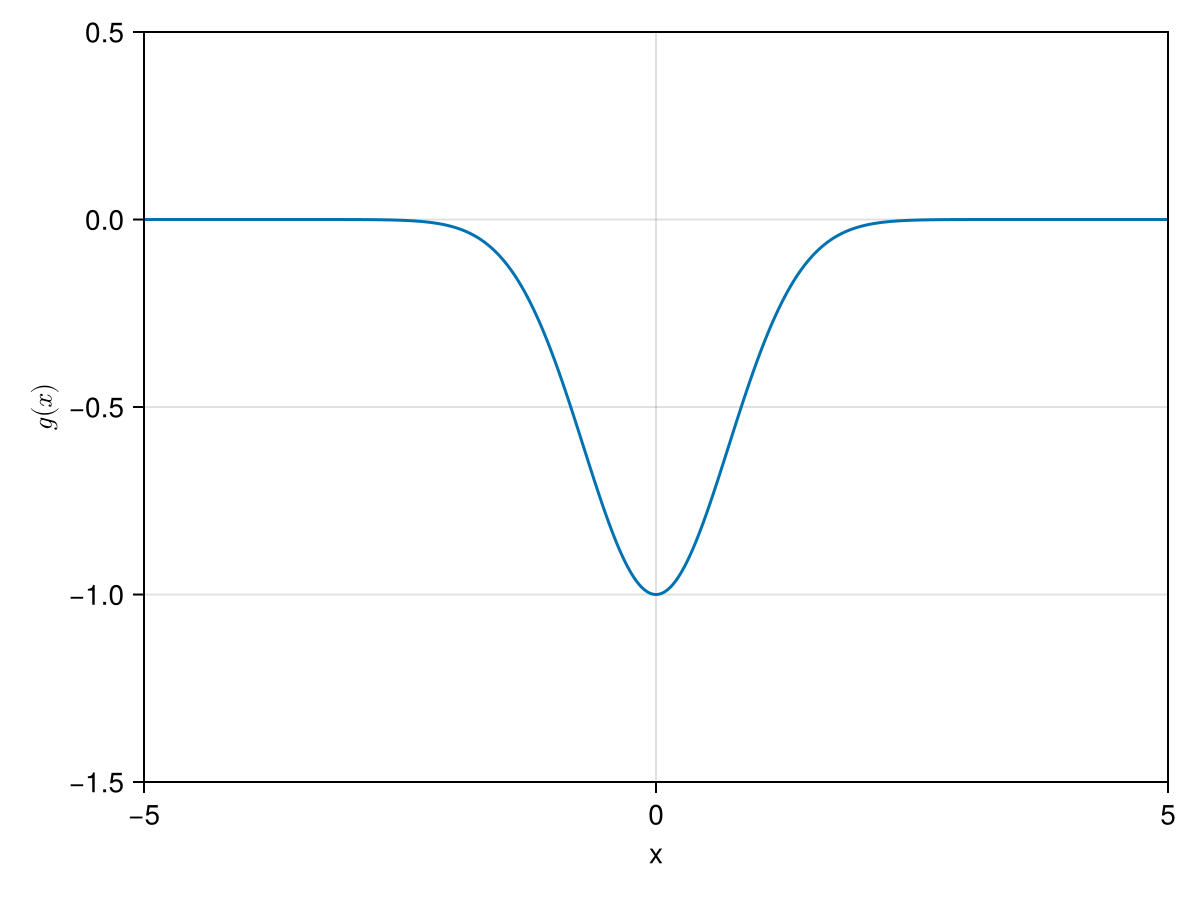

In [14]:
g(x)=-exp(-x^2)
∇g(x)=2*x*exp(-x^2)
xplot=-5:0.01:5
yplot=[g(x) for x in xplot];
fig = Figure()
ax = Axis(fig[1, 1], xlabel = "x", ylabel = L"$g(x)$",limits=(-5,5,-1.5,0.5))
lines!(ax,xplot,yplot)
fig

## Example 2.3.2 with Standard Gradient Descent 

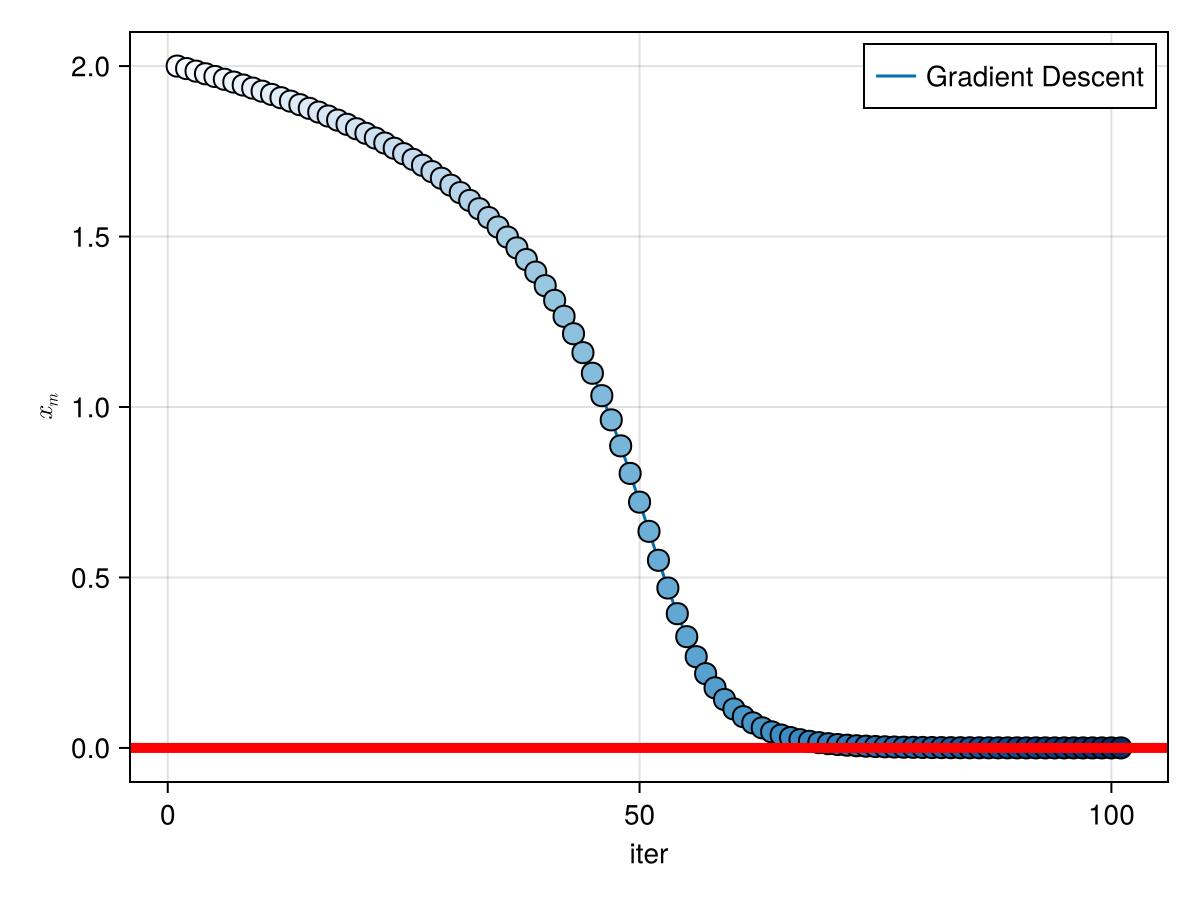

In [15]:
x0=2.0 #initial guess of xm
alpha=0.1 #learning rate
data=[Point1D(x0,g(x0))]
x=x0
for i in 1 : 100
    x-=alpha*∇g(x)
    push!(data,Point1D(x,g(x)))
end

fig_conv = Figure()
ax_conv = Axis(fig_conv[1, 1], xlabel = "iter", ylabel = L"x_m")
lines!(ax_conv,getproperty.(data, :x);label="Gradient Descent")
axislegend(ax_conv,  position = :rt,orientation = :vertical)

scatter!(ax_conv,getproperty.(data,:x);
    color=1:length(data),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Blues,
    markersize=15)

hlines!(ax_conv,0.0;color=:red,linewidth=5.0)
fig_conv

* The figure above shows that if we start with intial guess of $x_0=2.0$, gradient descent takes more than 50 iterations to converge to an acceptable value if we use  $\alpha=0.1$.
* Initially, the value of $x$ decreases very slowly because the gradient of $g(x)$ is very small for large values of $x$.  After a few iterations, the value of $x$ decreases very quickly because the gradient of $x$ increases when $x$ gets smaller.

## Example 2.3.2 with Momentum 

Now let's try using Momentum to find the minimum of $g(x)$

In [16]:
x0=2.0 #initial guess of x0
alpha=0.1 #learning rate
beta=0.6 #momentum
v=0.0
x=x0
data_m=[Point1D(x0,g(x0))]
for i in 1 : 100
    v=beta*v-alpha*∇g(x)
    x+=v
    push!(data_m,Point1D(x,g(x)))
end

## Example 2.3.2 with Nesterov Momentum 


Using Nesterov Momentum to find the minimum of $g(x)$

In [17]:
x0=2.0 #initial guess of x0
alpha=0.1 #learning rate
beta=0.6
v=0.0
x=x0
data_nm=[Point1D(x0,g(x0))]
for i in 1 : 100
    v =beta*v-alpha*∇g(x+beta*v)
    x+=v
    push!(data_nm,Point1D(x,g(x)))
end

Plotting the convergence and analysing the rate of convergence for all 3 methods.

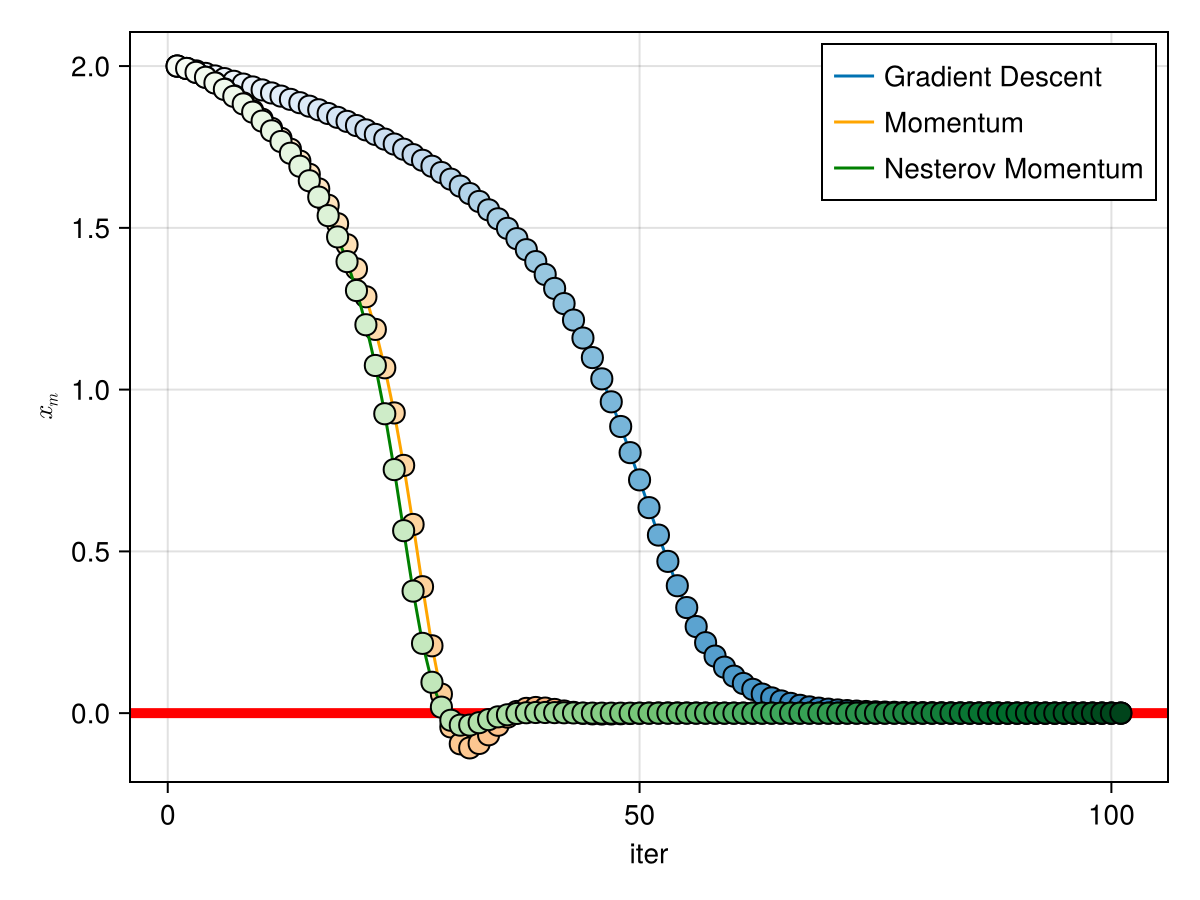

In [18]:
fig_conv = Figure()
ax_conv = Axis(fig_conv[1, 1], xlabel = "iter", ylabel = L"x_m")
lines!(ax_conv,getproperty.(data, :x);label="Gradient Descent")


scatter!(ax_conv,getproperty.(data,:x);
    color=1:length(data),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Blues,
    markersize=15)

hlines!(ax_conv,0.0;color=:red,linewidth=5.0)


lines!(ax_conv,getproperty.(data_m, :x),label="Momentum",color=:orange)
scatter!(ax_conv,getproperty.(data_m,:x);
    color=1:length(data_m),
    strokewidth=1,
    strokecolor=:black,
    colormap = :OrRd,
    markersize=15)

lines!(ax_conv,getproperty.(data_nm, :x),label="Nesterov Momentum",color=:green)
scatter!(ax_conv,getproperty.(data_nm,:x);
    color=1:length(data_nm),
    strokewidth=1,
    strokecolor=:black,
    colormap = :Greens,
    markersize=15)

axislegend(ax_conv,  position = :rt,orientation = :vertical)
fig_conv

You will see from the above example that momentum converges faster for this example.  Nesterov Momentum converges fastest.  The standard gradient descent method converges very slowly because the initial gradients were very small.

---

<u>Exercise Ex04:</u> Write a Julia code to find the minimum of the function $h(x)=(x^3-x)^2$.  Plot the convergence of the scheme that you have chosen to use.

----

---

**Class Demo 01:**
Write a Julia code that uses Gradient Descent to find the minimum of the function 

$A(r)=2\pi r^2+2/r$

---